<a href="https://colab.research.google.com/github/specM7/DSGP_Group_33_Brain_Tumor_Predictor/blob/NoTumor-%26-Chatbot-Ahshaan-2506751/Resnet_MRI_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive to access dataset and save trained model
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Import numerical and visualization libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import TensorFlow and Keras modules
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
# Define dataset directory containing MRI and Non-MRI images
dataset_dir = "/content/drive/MyDrive/Validate_MRI_Image/MRIDataset"


In [4]:
# Define image size and batch size
img_size = 224
batch_size = 16

# Create data generator with normalization and validation split
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    validation_split=0.2     # Split dataset into training and validation sets
)

# Load training dataset
train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# Load validation dataset
val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)


Found 9547 images belonging to 2 classes.
Found 2386 images belonging to 2 classes.


In [5]:
# Load ResNet50 pretrained on ImageNet without top classification layers
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
# Freeze ResNet layers to retain pretrained feature extraction
for layer in base_model.layers:
    layer.trainable = False


In [7]:
# Add custom layers for MRI classification
x = base_model.output
x = GlobalAveragePooling2D()(x)       # Convert feature maps into vector
x = Dense(128, activation='relu')(x)  # Fully connected layer
output = Dense(1, activation='sigmoid')(x)  # Binary output layer

# Create final model
model = Model(inputs=base_model.input, outputs=output)


In [8]:
# Compile model using Adam optimizer and binary cross-entropy loss
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [9]:
# Define number of training epochs
epochs = 15

# Train the model using training and validation datasets
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
183/597 ━━━━━━━━━━━━━━━━━━━━ 26:42 4s/step - accuracy: 0.7513 - loss: 0.4923

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


597/597 ━━━━━━━━━━━━━━━━━━━━ 2805s 5s/step - accuracy: 0.8260 - loss: 0.3814 - val_accuracy: 0.9686 - val_loss: 0.1686
Epoch 2/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 2021s 3s/step - accuracy: 0.9430 - loss: 0.1528 - val_accuracy: 0.9832 - val_loss: 0.0905
Epoch 3/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 2010s 3s/step - accuracy: 0.9613 - loss: 0.1066 - val_accuracy: 0.9484 - val_loss: 0.1193
Epoch 4/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 2047s 3s/step - accuracy: 0.9633 - loss: 0.1016 - val_accuracy: 0.9858 - val_loss: 0.0443
Epoch 5/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 2037s 3s/step - accuracy: 0.9742 - loss: 0.0781 - val_accuracy: 0.9631 - val_loss: 0.0835
Epoch 6/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 2020s 3s/step - accuracy: 0.9704 - loss: 0.0815 - val_accuracy: 0.9941 - val_loss: 0.0291
Epoch 7/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 2006s 3s/step - accuracy: 0.9795 - loss: 0.0632 - val_accuracy: 0.9824 - val_loss: 0.0444
Epoch 8/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 2037s 3s/step - accuracy: 0.9775 - loss: 0.0673 - val_accurac

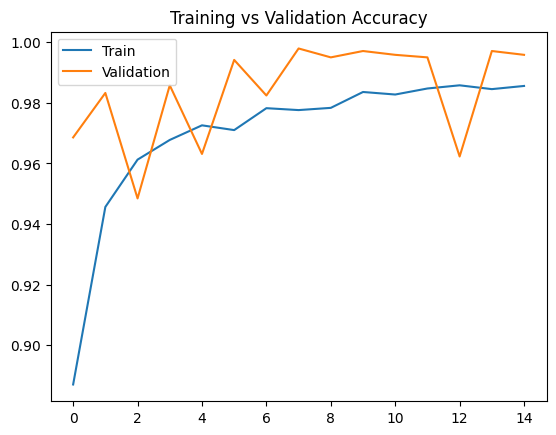

In [10]:
# Plot accuracy graph to monitor training performance
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.legend(["Train","Validation"])
plt.show()


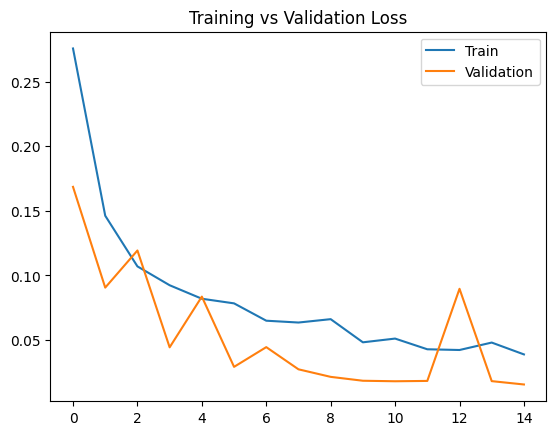

In [11]:
# Plot loss graph to check overfitting or underfitting
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.legend(["Train","Validation"])
plt.show()


In [12]:
# Evaluate model accuracy using validation dataset
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy:", val_acc)


150/150 ━━━━━━━━━━━━━━━━━━━━ 414s 3s/step - accuracy: 0.9941 - loss: 0.0207
Validation Accuracy: 0.9958088994026184


150/150 ━━━━━━━━━━━━━━━━━━━━ 429s 3s/step


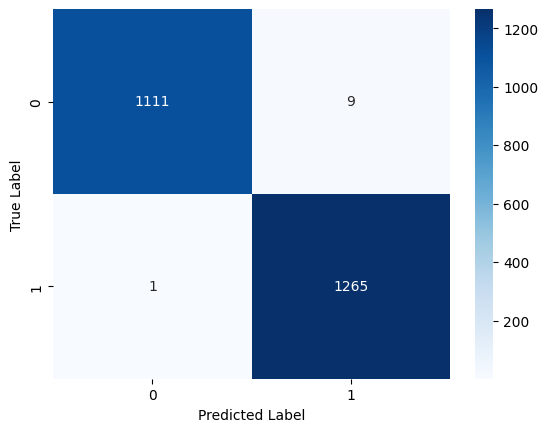

In [13]:
# Predict validation dataset labels
pred_probs = model.predict(val_generator)
pred_labels = (pred_probs > 0.5).astype(int).ravel()

# Get true labels
true_labels = val_generator.classes

# Create confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [14]:
# Display precision, recall, and F1-score
print(classification_report(true_labels, pred_labels))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1120
           1       0.99      1.00      1.00      1266

    accuracy                           1.00      2386
   macro avg       1.00      1.00      1.00      2386
weighted avg       1.00      1.00      1.00      2386



In [15]:
# Save trained ResNet MRI validation model
model.save("/content/drive/MyDrive/Validate_MRI_Image/MRIDataset/ResnetMri_Validator.h5")
print("Model saved successfully")


Model saved successfully
